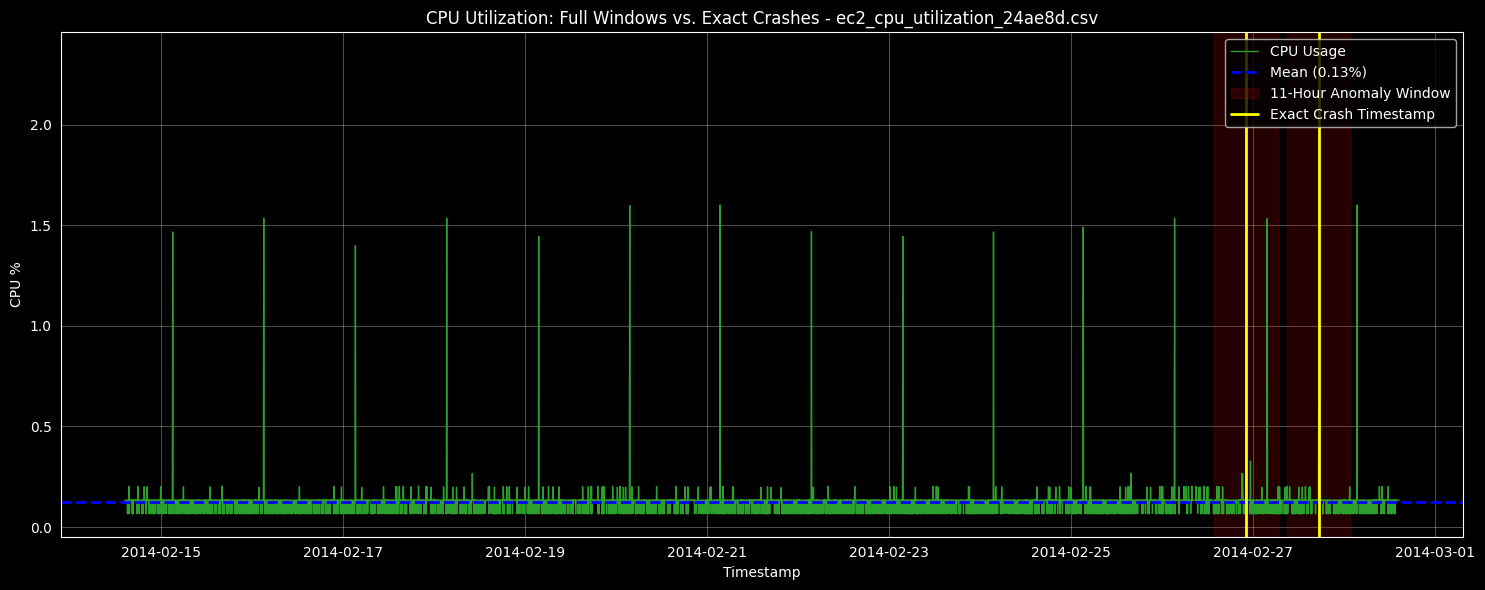

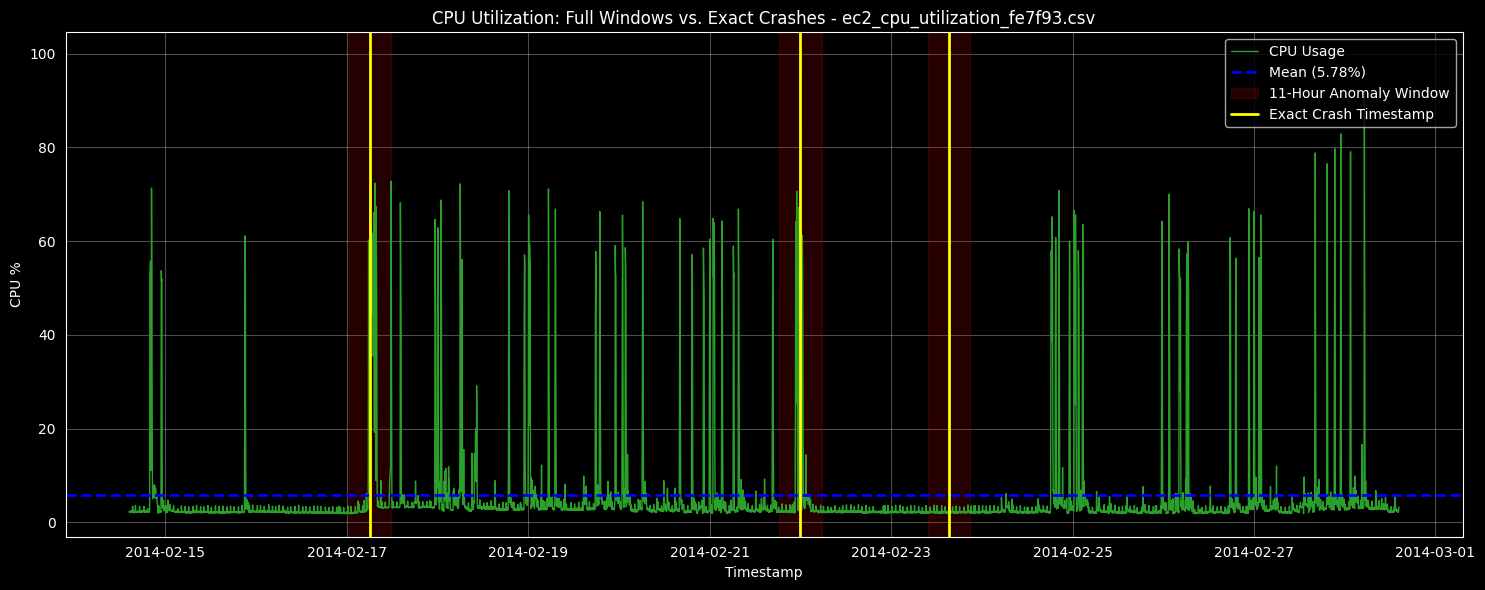

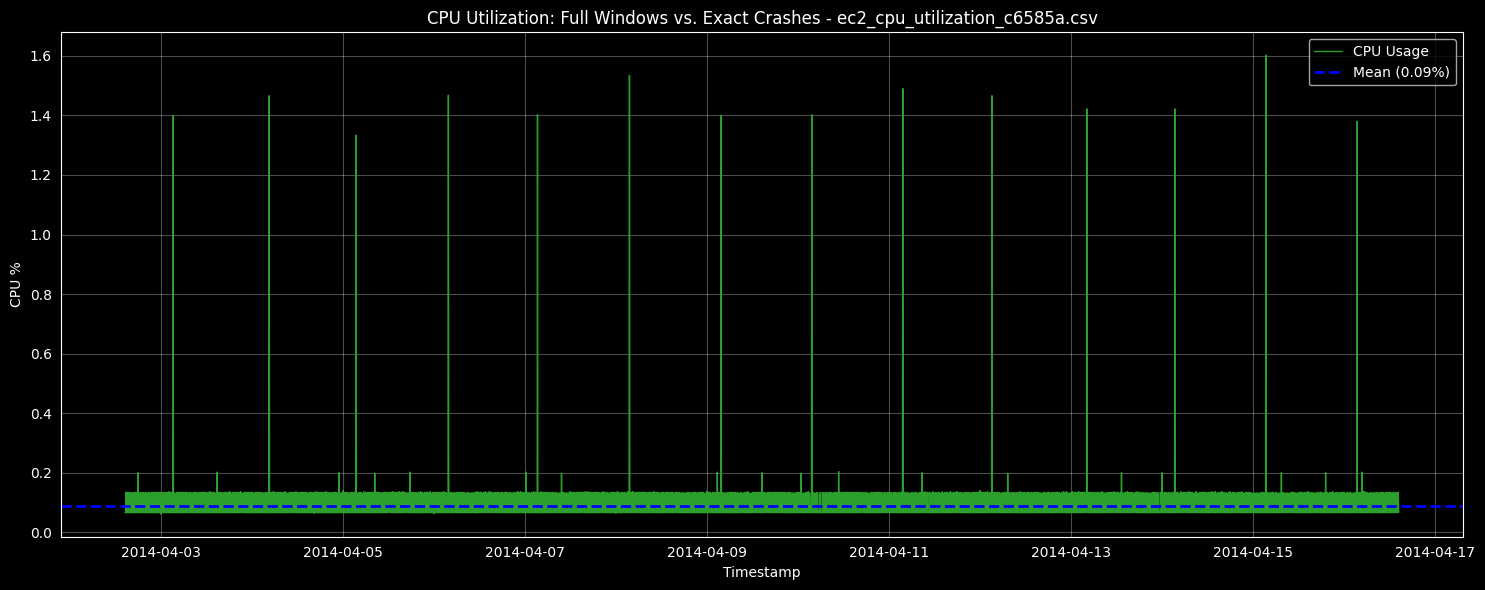

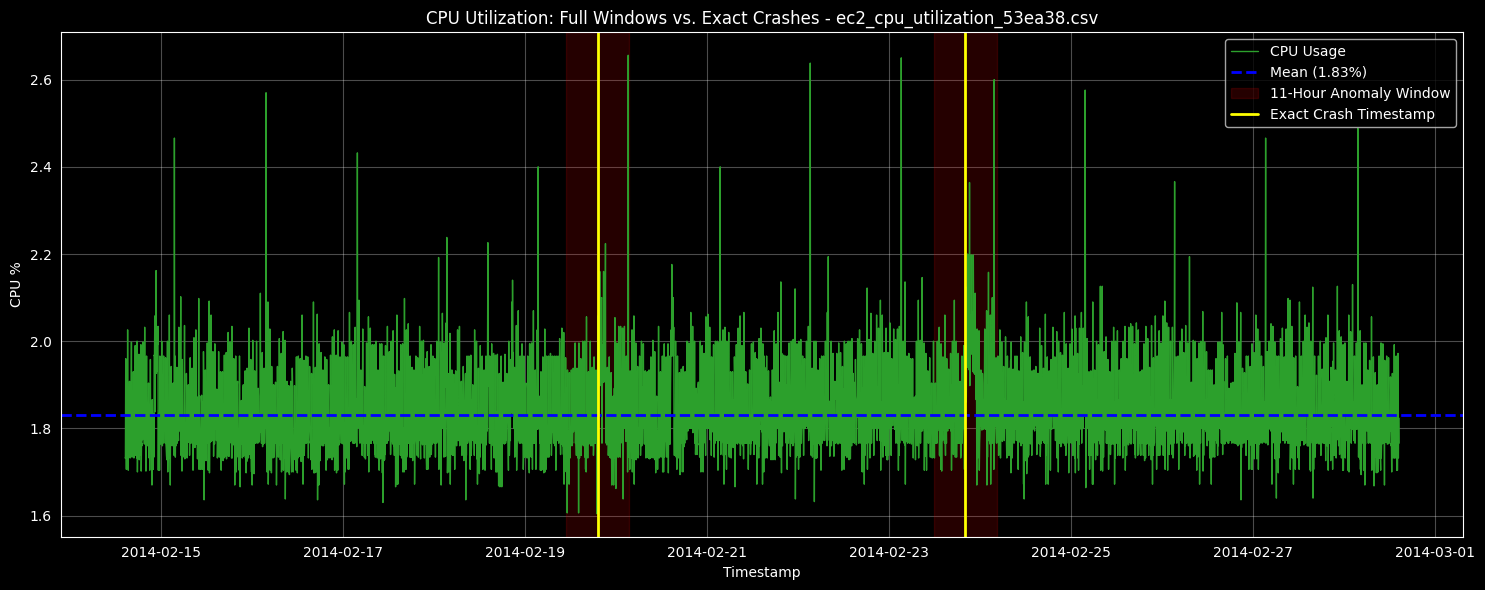

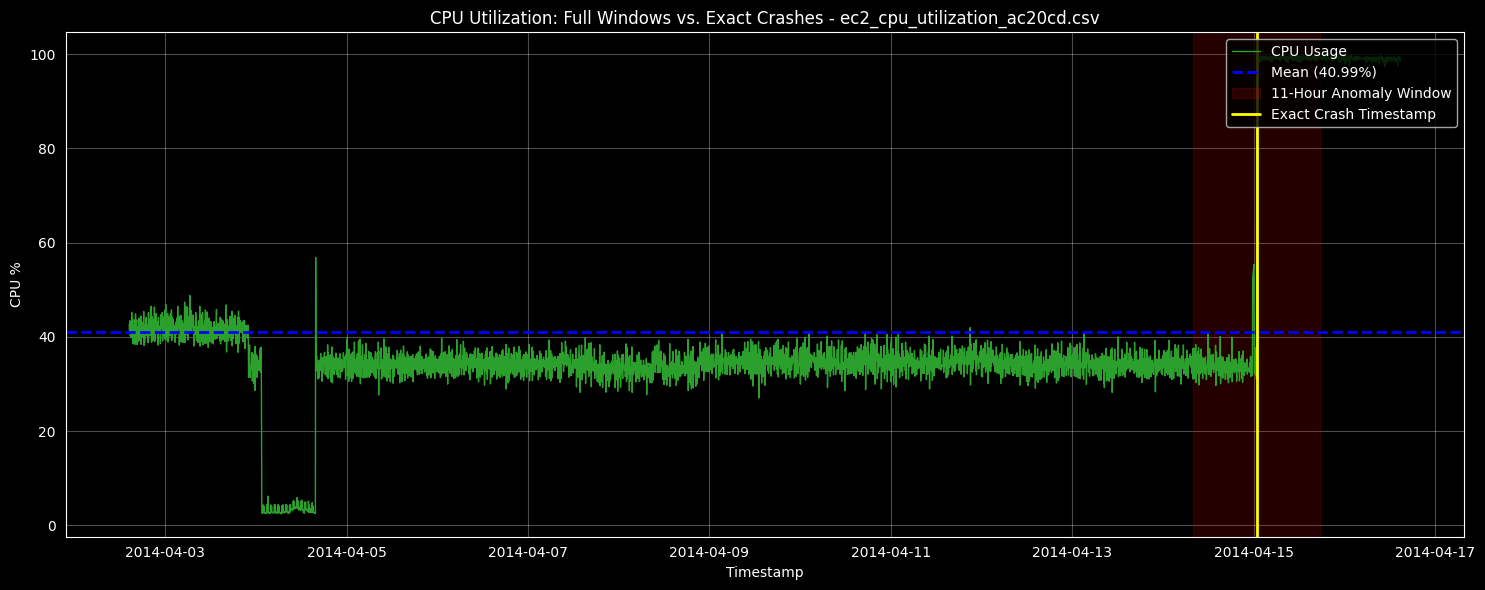

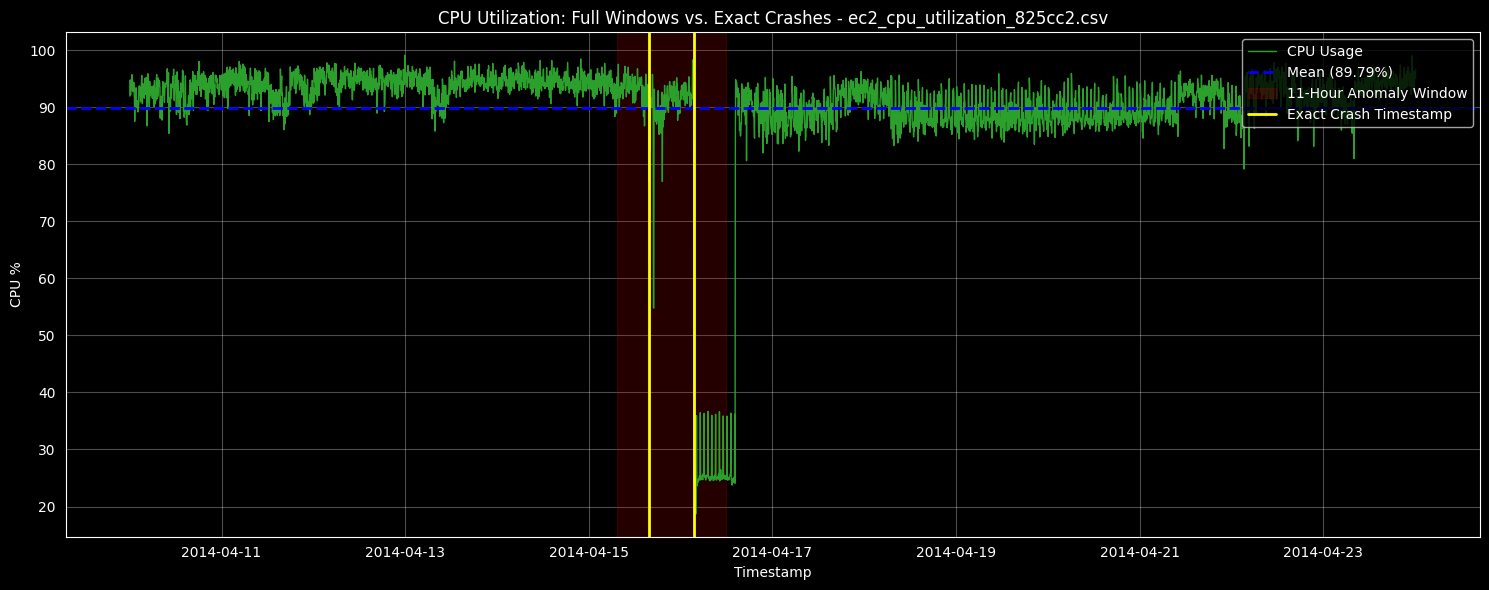

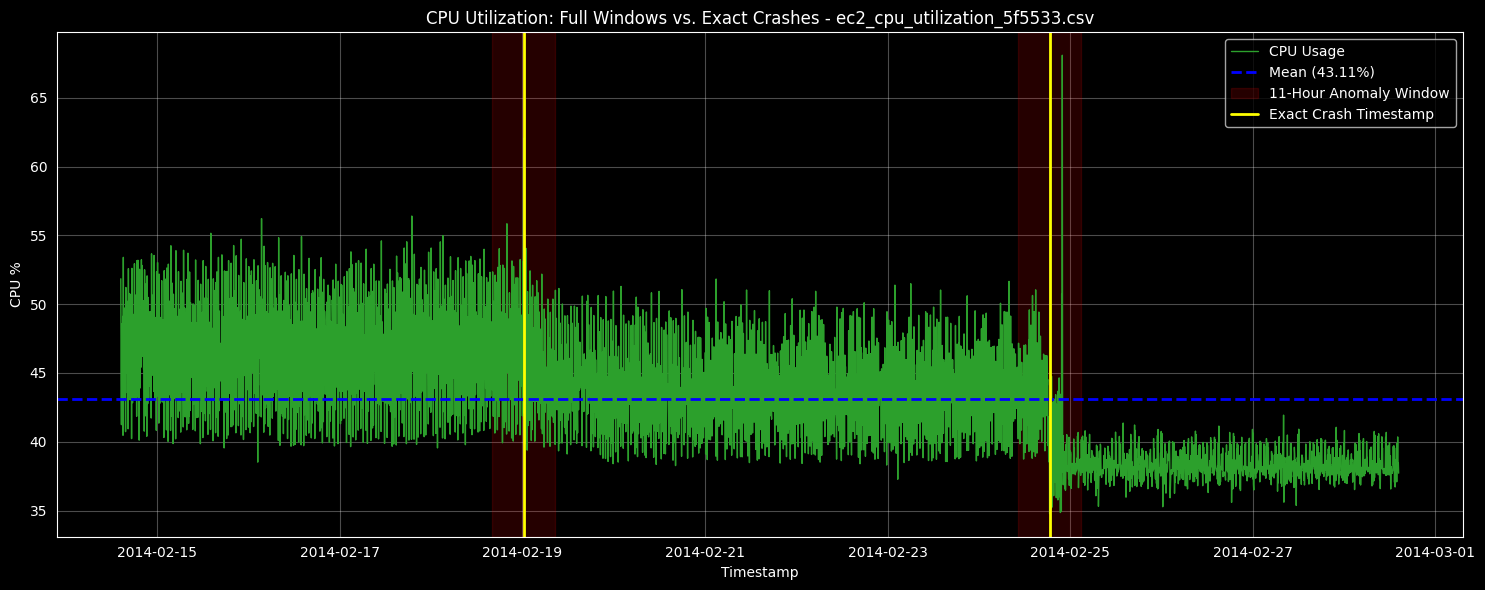

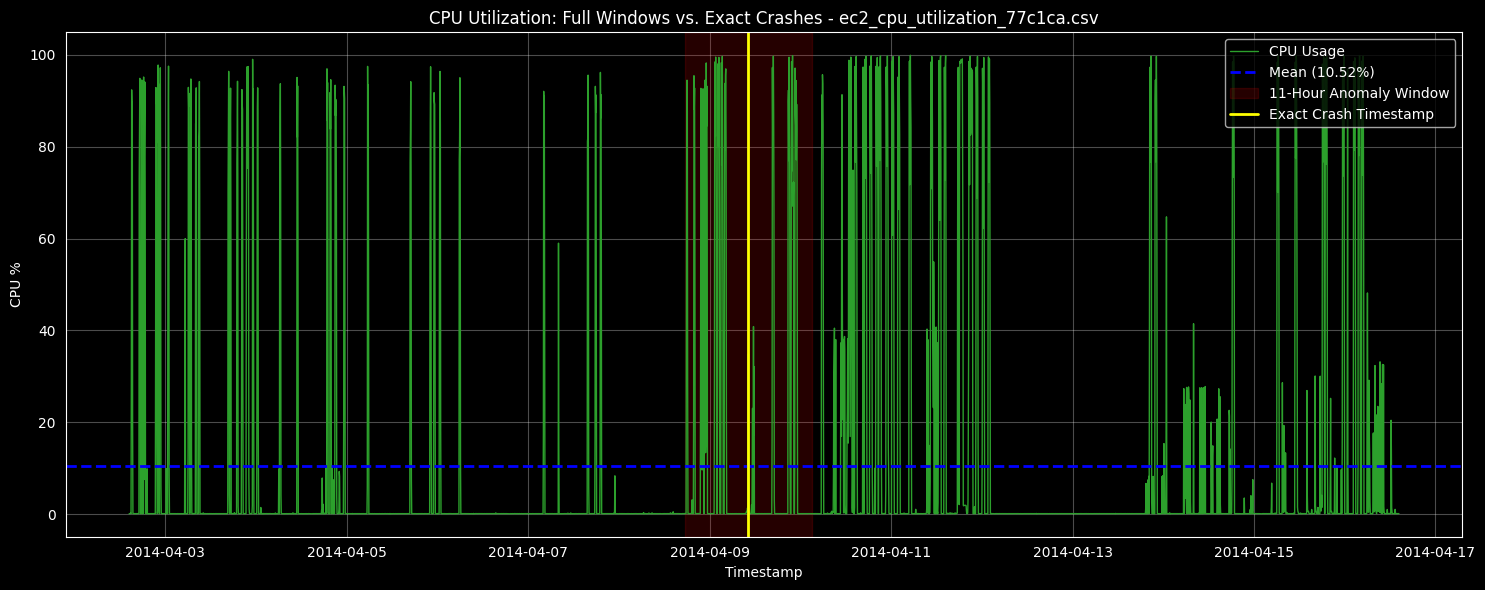

In [2]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import json

csv_files = glob.glob("data/*.csv")

# 1. Load BOTH json files
with open('labels/combined_windows.json') as f:
    windows_dict = json.load(f)

with open('labels/combined_labels.json') as f:
    labels_dict = json.load(f)

for file_path in csv_files:
    file_name = os.path.basename(file_path)

    df = pd.read_csv(file_path)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    mean_val = df['value'].mean()

    json_key = f"realAWSCloudwatch/{file_name}"

    # Extract from both dicts
    anomaly_windows = windows_dict.get(json_key, [])
    exact_timestamps = labels_dict.get(json_key, [])

    plt.figure(figsize=(15, 6))
    plt.plot(df['timestamp'], df['value'], color='#2ca02c', linewidth=1, label='CPU Usage')
    plt.axhline(y=mean_val, color='blue', linestyle='--', linewidth=2, label=f'Mean ({mean_val:.2f}%)')

    # Plot the massive NAB windows
    for window in anomaly_windows:
        start_time = pd.to_datetime(window[0])
        end_time = pd.to_datetime(window[1])
        plt.axvspan(start_time, end_time, color='red', alpha=0.15, label='11-Hour Anomaly Window')

    # Plot ONLY the exact crashes
    if exact_timestamps:
        for t_crash in exact_timestamps:
            crash_dt = pd.to_datetime(t_crash)

            # Draw the exact moment of failure
            plt.axvline(x=crash_dt, color='yellow', linestyle='-', linewidth=2, label='Exact Crash Timestamp')

    # Clean up duplicate labels in legend
    handles, labels = plt.gca().get_legend_handles_labels()
    if handles:
        by_label = dict(zip(labels, handles))
        plt.legend(by_label.values(), by_label.keys(), loc="upper right")

    plt.title(f"CPU Utilization: Full Windows vs. Exact Crashes - {file_name}")
    plt.ylabel("CPU %")
    plt.xlabel("Timestamp")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()